In [3]:
import pandas as pd 
import matplotlib.pyplot as plt 
import numpy as np

In [115]:
# reading data
default_df = pd.read_csv("trajectory_data/no_connection_time_optimization_default_samples_circle_2_0_obstacle.csv")
connection_time_optimized_df = pd.read_csv("trajectory_data/default_samples_circle_2_0_obstacle.csv")
near_obstacle_df = pd.read_csv("trajectory_data/circle_obstacle_0_1m_away.csv")
fast_speed_far_obstacle_df = pd.read_csv("trajectory_data/fast_speed_far_obstacle.csv")
fast_speed_robot_obstacle_df = pd.read_csv("trajectory_data/fast_speed_robot_obstacle.csv")

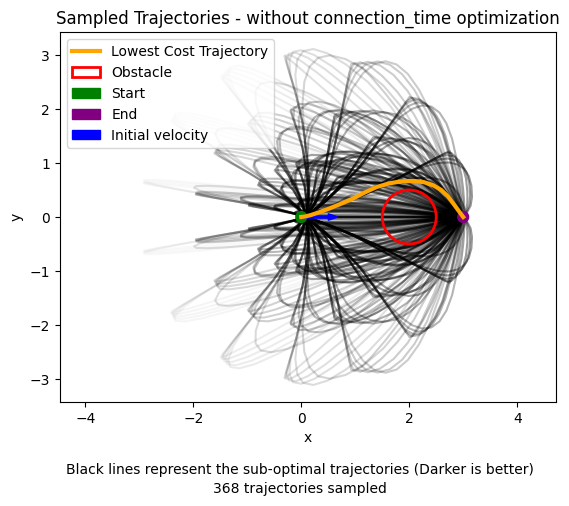

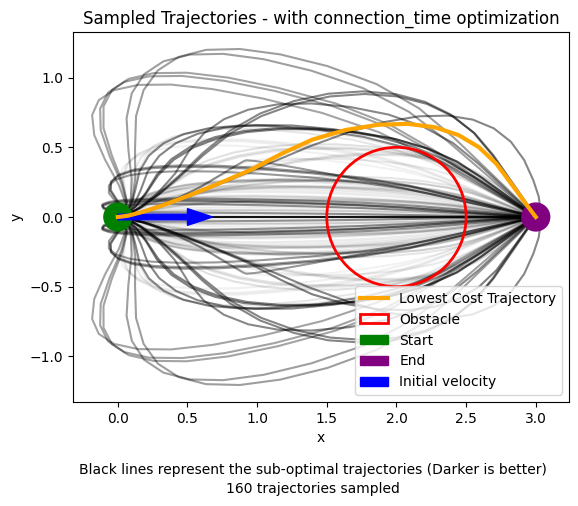

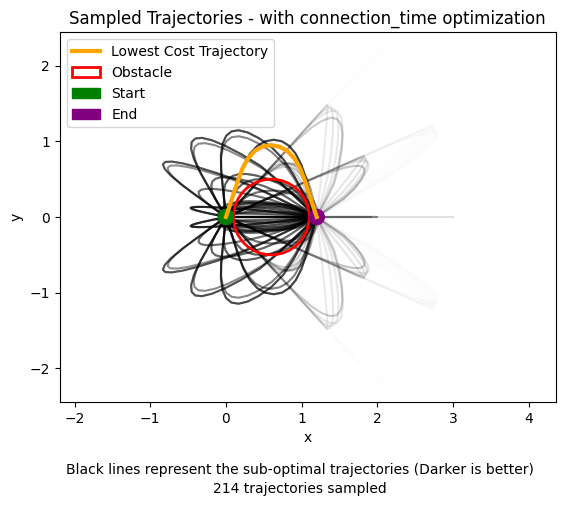

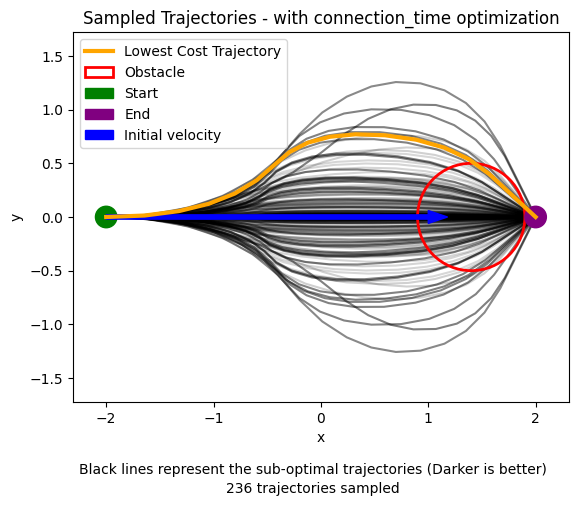

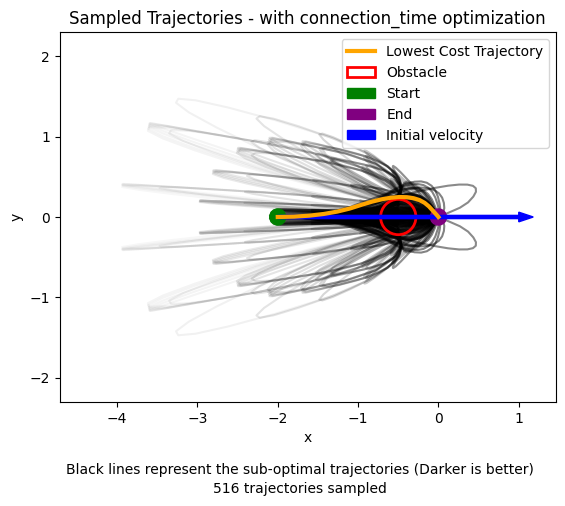

In [116]:
import matplotlib.pyplot as plt

def plot_trajectories(df, title):

    # Normalize the 'total_cost' column to [0, 1]
    df['normalized_cost'] = (df['total_cost'] - df['total_cost'].min()) / (df['total_cost'].max() - df['total_cost'].min())

    # Plot all other trajectories
    for _, row in df.iterrows():
        x_coords = [row[f'x{i}'] for i in range(21)]
        y_coords = [row[f'y{i}'] for i in range(21)]
        plt.plot(x_coords, y_coords, color='black', alpha=0.5 * (1-row['normalized_cost']), zorder=1)

    # Find the row with the lowest total cost
    min_cost_row = df.loc[df['total_cost'].idxmin()]

    # Extract the x and y coordinates of the trajectory
    x_coords_min = [min_cost_row[f'x{i}'] for i in range(21)]
    y_coords_min = [min_cost_row[f'y{i}'] for i in range(21)]

    # Plot the trajectory with the lowest cost
    plt.plot(x_coords_min, y_coords_min, label='Lowest Cost Trajectory', color='orange', linewidth=3)

    # Plot the circle obstacle
    circle = plt.Circle((min_cost_row['circle_obst_x'], min_cost_row['circle_obst_y']), min_cost_row['circle_obst_rad'], color='r', label='Obstacle', fill=False, linewidth=2)
    plt.gca().add_patch(circle)

    # Plot start and end positions
    start = plt.Circle((min_cost_row['start_x'], min_cost_row['start_y']), 0.1, color='g', label='Start', fill=True)
    end = plt.Circle((min_cost_row['end_x'], min_cost_row['end_y']), 0.1, color='purple', label='End', fill=True)
    plt.gca().add_patch(start)
    plt.gca().add_patch(end)

    # Draw a vector to represent the initial velocity
    if min_cost_row['initial_vel(x)'] != 0 or min_cost_row['initial_vel(y)'] != 0:
        plt.arrow(min_cost_row['start_x'], min_cost_row['start_y'], min_cost_row['initial_vel(x)'], min_cost_row['initial_vel(y)'], color='blue', width=0.04, label='Initial velocity')    

    plt.xlabel('x')
    plt.ylabel('y')
    # Add description text outside of the plot
    plt.figtext(0.5, -0.04, 'Black lines represent the sub-optimal trajectories (Darker is better)', ha='center')
    plt.figtext(0.5, -0.08, f'{len(df)-1} trajectories sampled', ha='center')
    plt.title(title)
    plt.legend()

    # Set equal aspect ratio
    plt.axis('equal')
    plt.show()

plot_trajectories(default_df, title='Sampled Trajectories - without connection_time optimization')
plot_trajectories(connection_time_optimized_df, title='Sampled Trajectories - with connection_time optimization')
plot_trajectories(near_obstacle_df, title='Sampled Trajectories - with connection_time optimization')
plot_trajectories(fast_speed_far_obstacle_df, title='Sampled Trajectories - with connection_time optimization')
plot_trajectories(fast_speed_robot_obstacle_df, title='Sampled Trajectories - with connection_time optimization')



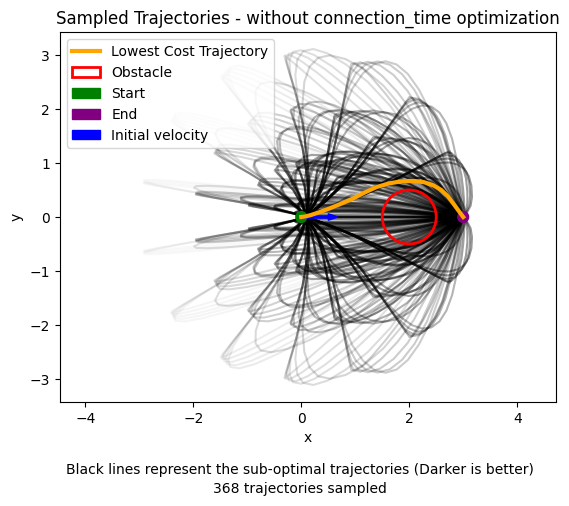

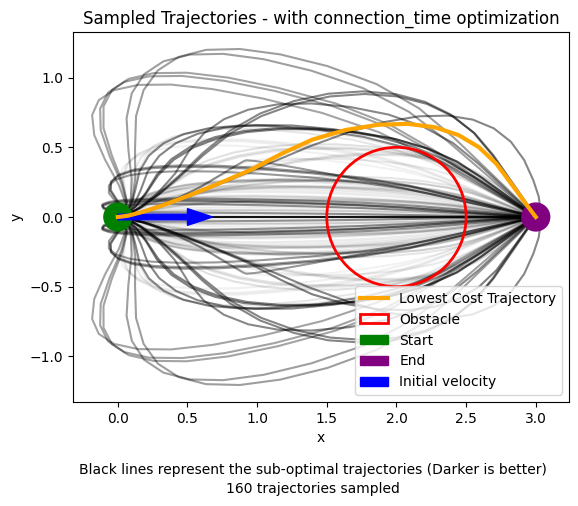

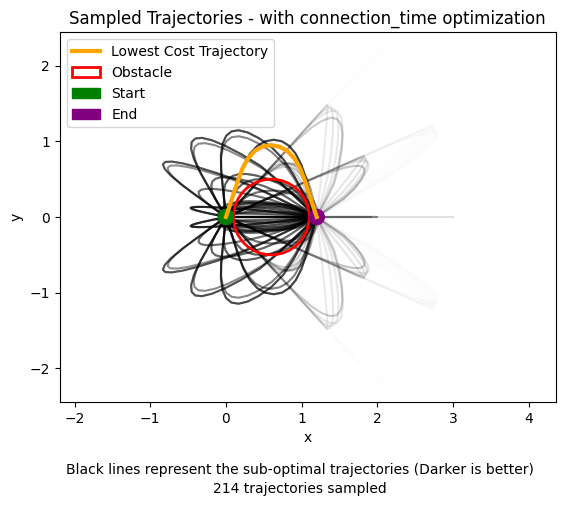

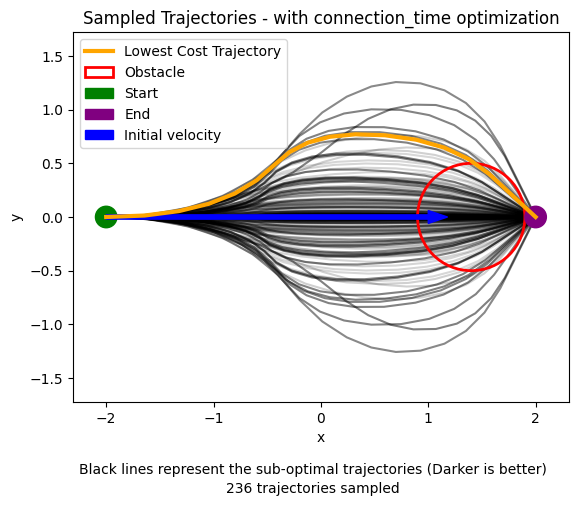

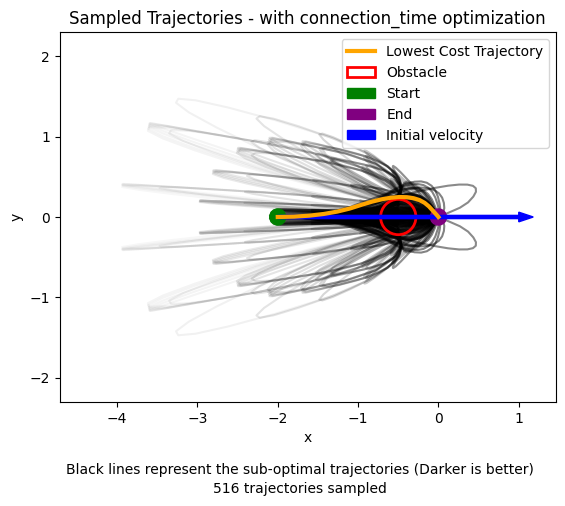

In [114]:
import matplotlib.pyplot as plt

def plot_trajectories(df, title):

    # Normalize the 'total_cost' column to [0, 1]
    df['normalized_cost'] = (df['total_cost'] - df['total_cost'].min()) / (df['total_cost'].max() - df['total_cost'].min())

    # Plot all other trajectories
    for _, row in df.iterrows():
        x_coords = [row[f'x{i}'] for i in range(21)]
        y_coords = [row[f'y{i}'] for i in range(21)]
        plt.plot(x_coords, y_coords, color='black', alpha=0.5 * (1-row['normalized_cost']), zorder=1)

    # Find the row with the lowest total cost
    min_cost_row = df.loc[df['total_cost'].idxmin()]

    # Extract the x and y coordinates of the trajectory
    x_coords_min = [min_cost_row[f'x{i}'] for i in range(21)]
    y_coords_min = [min_cost_row[f'y{i}'] for i in range(21)]

    # Plot the trajectory with the lowest cost
    plt.plot(x_coords_min, y_coords_min, label='Lowest Cost Trajectory', color='orange', linewidth=3)

    # Plot the circle obstacle
    circle = plt.Circle((min_cost_row['circle_obst_x'], min_cost_row['circle_obst_y']), min_cost_row['circle_obst_rad'], color='r', label='Obstacle', fill=False, linewidth=2)
    plt.gca().add_patch(circle)

    # Plot start and end positions
    start = plt.Circle((min_cost_row['start_x'], min_cost_row['start_y']), 0.1, color='g', label='Start', fill=True)
    end = plt.Circle((min_cost_row['end_x'], min_cost_row['end_y']), 0.1, color='purple', label='End', fill=True)
    plt.gca().add_patch(start)
    plt.gca().add_patch(end)

    # Draw a vector to represent the initial velocity
    if min_cost_row['initial_vel(x)'] != 0 or min_cost_row['initial_vel(y)'] != 0:
        plt.arrow(min_cost_row['start_x'], min_cost_row['start_y'], min_cost_row['initial_vel(x)'], min_cost_row['initial_vel(y)'], color='blue', width=0.04, label='Initial velocity')    

    plt.xlabel('x')
    plt.ylabel('y')
    # Add description text outside of the plot
    plt.figtext(0.5, -0.04, 'Black lines represent the sub-optimal trajectories (Darker is better)', ha='center')
    plt.figtext(0.5, -0.08, f'{len(df)-1} trajectories sampled', ha='center')
    plt.title(title)
    plt.legend()

    # Set equal aspect ratio
    plt.axis('equal')
    plt.show()

plot_trajectories(default_df, title='Sampled Trajectories - without connection_time optimization')
plot_trajectories(connection_time_optimized_df, title='Sampled Trajectories - with connection_time optimization')
plot_trajectories(near_obstacle_df, title='Sampled Trajectories - with connection_time optimization')
plot_trajectories(fast_speed_far_obstacle_df, title='Sampled Trajectories - with connection_time optimization')
plot_trajectories(df, title='Sampled Trajectories - with connection_time optimization')

